# **Business Understanding**

Perform sentiment analysis on text such as customer reviews or social media comments to classify user opinions into three categories:

-Positive

-Negative

-Neutral

# **Data Understanding**

In [34]:
# import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler


# Download necessary resources for NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Unnamed: 0.1 = Usually a duplicated index column (possibly from the CSV export process).

Unnamed: 0 = Also possible unique index or ID for each row.

Text = The text content (possibly a tweet, comment, or post).

Sentiment = The sentiment of the text, such as positive, neutral, or negative.

Timestamp = The time the text was posted.

User = The name or ID of the user who posted it.

Platform = The platform the data comes from (Twitter, Instagram, etc.).

Hashtags = The hashtags used in the text.

Retweets = The number of retweets of the post.

Likes = The number of likes of the post.

Country = The country the user is from or the location of the post.

Year = The year the post was created.

Month = The month the post was created.

Day = The day the post was created.

Hour = The time the post was created.

In [2]:
# read dataset
df = pd.read_csv('/content/3) Sentiment dataset.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


# **Data Preparation**

Initial Exploration of the Dataset

In [3]:
# Check column info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB
None


In [4]:
# change Timestamp column to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [5]:
# Drop unnecessary columns
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])

# recheck the column after cleaning
print(df.columns)

Index(['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags',
       'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')


In [6]:
# Displaying Basic Statistics
print("Descriptive Statistics:\n",)
df.describe()

Descriptive Statistics:



,Timestamp,Retweets,Likes,Year,Month,Day,Hour
count,732,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,2020-12-08 21:37:38.196721408,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
min,2010-05-15 15:30:00,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,2019-03-08 17:27:30,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,2021-09-20 14:30:00,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,2023-02-26 11:48:45,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,2023-10-22 20:45:00,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000
std,NaN,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414


**Exploratory Data Analysis**

how is the distribution of usage based on time

<ipython-input-7-479334f9d576>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=df, palette='coolwarm')


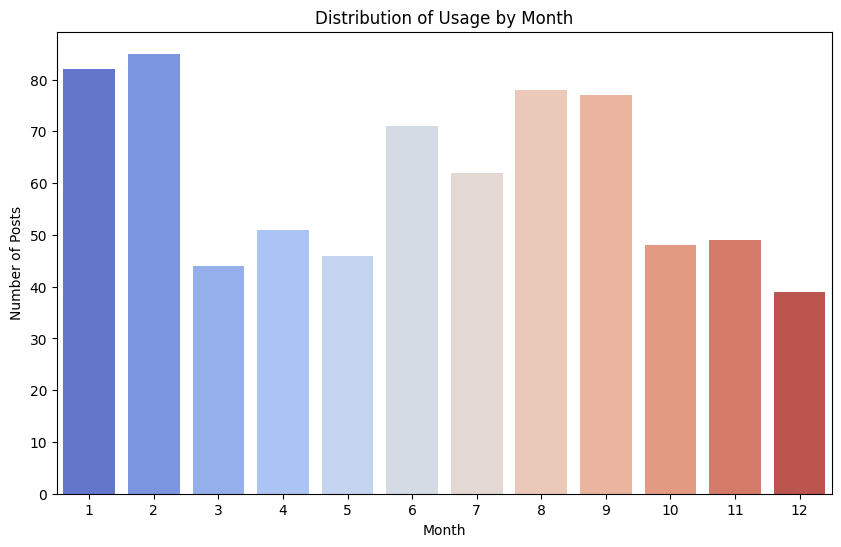

In [7]:
# Time Analysis by Month
plt.figure(figsize=(10, 6))
sns.countplot(x='Month', data=df, palette='coolwarm')
plt.title('Distribution of Usage by Month')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.show()

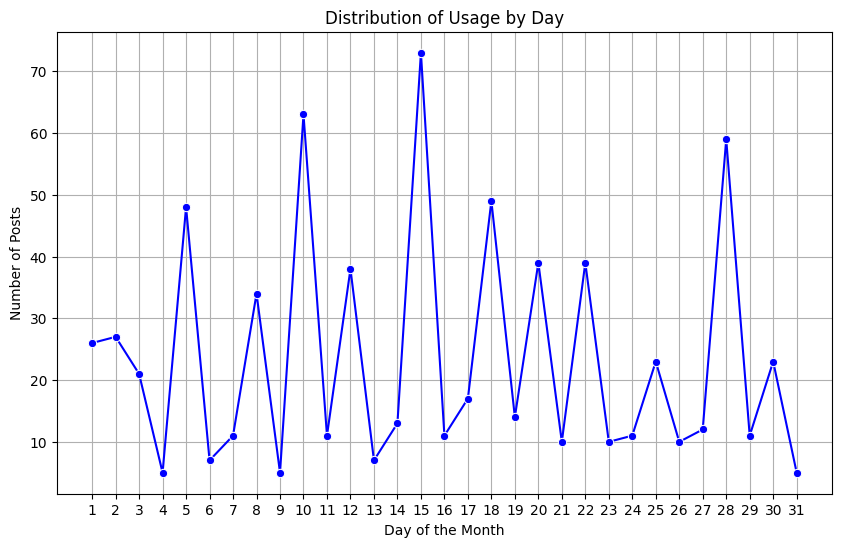

In [8]:
# Time Analysis by Day
plt.figure(figsize=(10, 6))
day_counts = df['Day'].value_counts().sort_index()
sns.lineplot(x=day_counts.index, y=day_counts.values, marker='o', color='b')
plt.title('Distribution of Usage by Day')
plt.xlabel('Day of the Month')
plt.ylabel('Number of Posts')
plt.xticks(range(1, 32))
plt.grid(True)
plt.show()

<ipython-input-9-dc6f0fc5fb87>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='coolwarm')


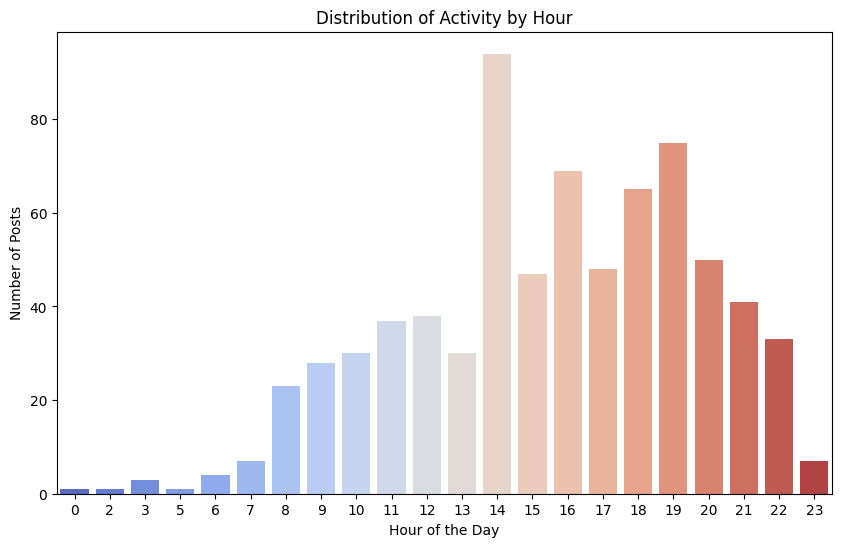

In [9]:
# Time Analysis by Hour
plt.figure(figsize=(10, 6))
sns.countplot(x='Hour', data=df, palette='coolwarm')
plt.title('Distribution of Activity by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Posts')
plt.show()

What are the most frequently used hashtags in the dataset?

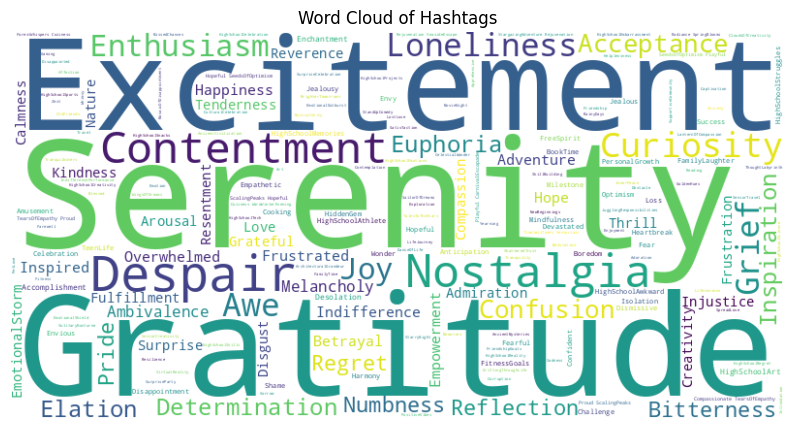

In [10]:
# 5. Hashtag Analysis
# Preparing data for hashtag analysis
all_hashtags = ' '.join(df['Hashtags'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_hashtags)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Hashtags')
plt.show()

Is there a difference in sentiment based on the platform used?

In [11]:
# Perform statistical analysis to see if there is a significant difference in sentiment across platforms
from scipy.stats import chi2_contingency

# Create a contingency table for sentiment vs platform
contingency_table = pd.crosstab(df['Platform'], df['Sentiment'])

# Perform chi-square test to check if there is a significant difference
chi2, p, _, _ = chi2_contingency(contingency_table)

print("Chi-square test result:")
print("Chi2 statistic:", chi2)
print("P-value:", p)

# If p-value < 0.05, it means there is a significant difference in sentiment based on platform
if p < 0.05:
    print("There is a significant difference in sentiment based on platform.")
else:
    print("There is no significant difference in sentiment based on platform.")

Chi-square test result:
Chi2 statistic: 973.7141915378156
P-value: 0.0005517146503072072
There is a significant difference in sentiment based on platform.


Which platform is most used for posting?

<ipython-input-12-9a18646cf1a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Platform', palette='Set2', order=df['Platform'].value_counts().index)


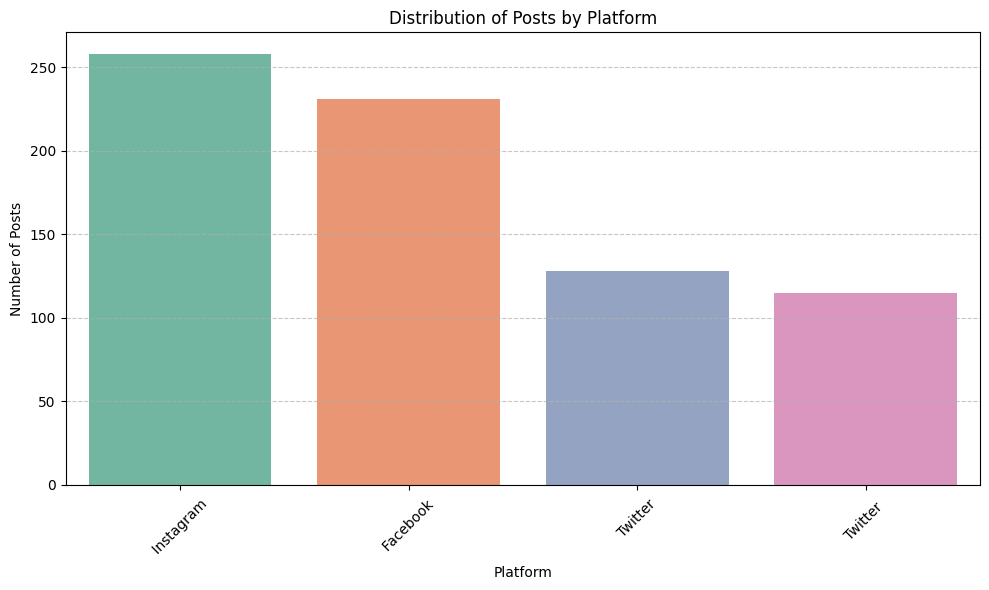

In [12]:
# Visualization of Platform Usage
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Platform', palette='Set2', order=df['Platform'].value_counts().index)
plt.title('Distribution of Posts by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
# Print unique values in the 'Platform' column
unique_platforms = df['Platform'].unique()
print("Unique platforms found in the dataset:")
for platform in unique_platforms:
    print("-", platform)

Unique platforms found in the dataset:
-  Twitter  
-  Instagram 
-  Facebook 
-  Twitter 


In [14]:
# Clean up the 'Platform' column by removing extra spaces and standardizing casing
df['Platform'] = df['Platform'].str.strip().str.capitalize()

<ipython-input-15-9a18646cf1a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Platform', palette='Set2', order=df['Platform'].value_counts().index)


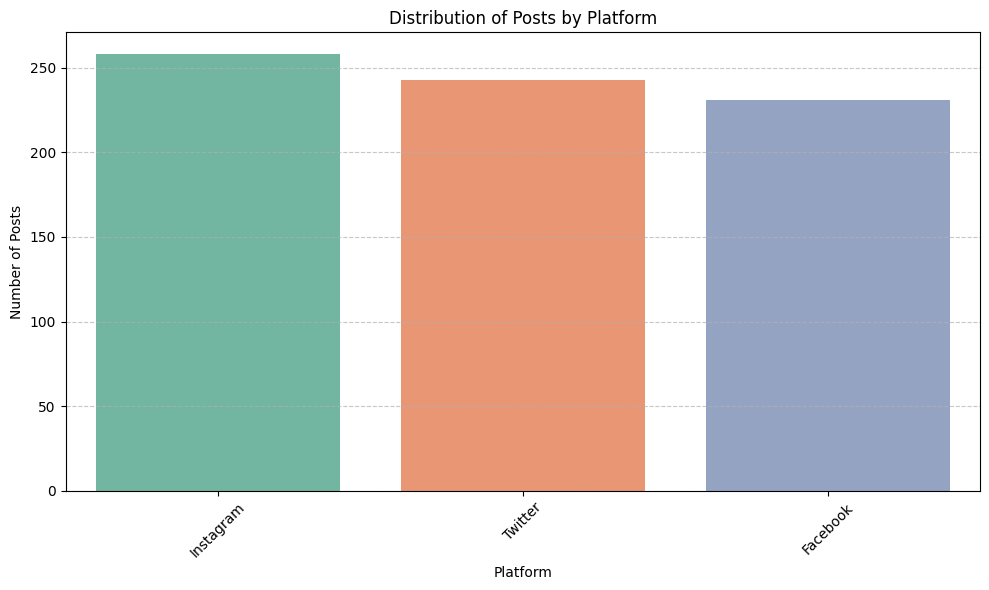

In [15]:
# Visualization of Platform Usage
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Platform', palette='Set2', order=df['Platform'].value_counts().index)
plt.title('Distribution of Posts by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Is there a positive relationship between the number of retweets and likes? (Do posts that are retweeted a lot tend to get more likes?)

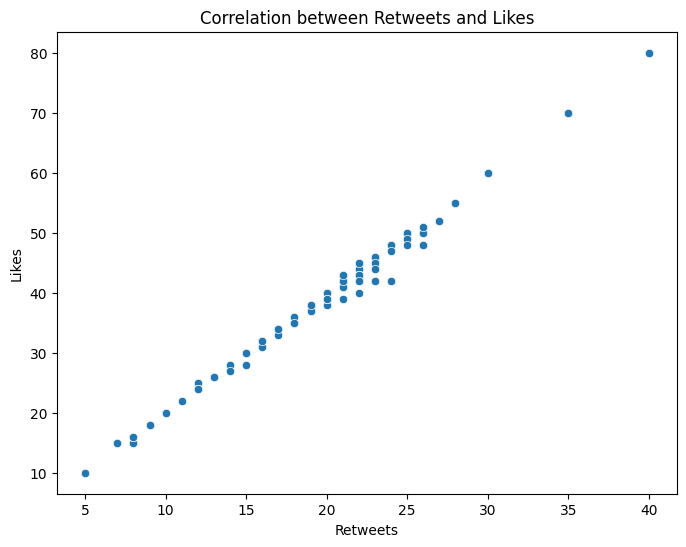

In [16]:
# Correlation between Retweets and Likes
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Retweets', y='Likes', data=df)
plt.title('Correlation between Retweets and Likes')
plt.xlabel('Retweets')
plt.ylabel('Likes')
plt.show()

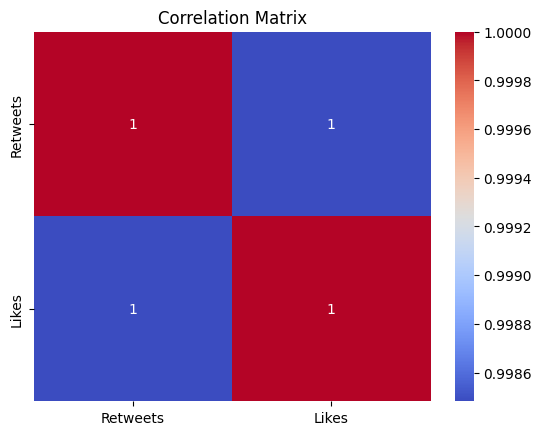

In [17]:
# Displaying Correlation Between Numeric Columns
correlation_matrix = df[['Retweets', 'Likes']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Clean the text data by:

- Lowercasing

- Removing punctuation

- Removing stopwords

- Applying stemming or lemmatization

In [18]:
# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [19]:
# Preprocessing function for text
def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = nltk.word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

In [20]:
# Apply the preprocessing to the 'Text' column
df['Cleaned_Text'] = df['Text'].apply(preprocess_text)

# Show the first few rows of the original and cleaned text
print(df[['Text', 'Cleaned_Text']].head())

                                                Text  \
0   Enjoying a beautiful day at the park!        ...   
1   Traffic was terrible this morning.           ...   
2   Just finished an amazing workout! 💪          ...   
3   Excited about the upcoming weekend getaway!  ...   
4   Trying out a new recipe for dinner tonight.  ...   

                       Cleaned_Text  
0       enjoying beautiful day park  
1          traffic terrible morning  
2        finished amazing workout 💪  
3  excited upcoming weekend getaway  
4  trying new recipe dinner tonight  


In [21]:
# Display all unique sentiment values in the dataset
print("Unique Sentiments in the Dataset:")
print(df['Sentiment'].unique())

Unique Sentiments in the Dataset:
[' Positive  ' ' Negative  ' ' Neutral   ' ' Anger        '
 ' Fear         ' ' Sadness      ' ' Disgust      ' ' Happiness    '
 ' Joy          ' ' Love         ' ' Amusement    ' ' Enjoyment    '
 ' Admiration   ' ' Affection    ' ' Awe          ' ' Disappointed '
 ' Surprise     ' ' Acceptance   ' ' Adoration    ' ' Anticipation '
 ' Bitter       ' ' Calmness     ' ' Confusion    ' ' Excitement   '
 ' Kind         ' ' Pride        ' ' Shame        ' ' Confusion '
 ' Excitement ' ' Shame ' ' Elation       ' ' Euphoria      '
 ' Contentment   ' ' Serenity      ' ' Gratitude     ' ' Hope          '
 ' Empowerment   ' ' Compassion    ' ' Tenderness    ' ' Arousal       '
 ' Enthusiasm    ' ' Fulfillment  ' ' Reverence     ' ' Compassion'
 ' Fulfillment   ' ' Reverence ' ' Elation   ' ' Despair         '
 ' Grief           ' ' Loneliness      ' ' Jealousy        '
 ' Resentment      ' ' Frustration     ' ' Boredom         '
 ' Anxiety         ' ' Intimid

Rule-Based Sentiment Classification

In [22]:
# Clean up whitespace
df['Sentiment'] = df['Sentiment'].str.strip()

# classify sentiment value
positive_words = [
    'positive', 'happiness', 'joy', 'love', 'admiration', 'affection', 'amusement', 'enjoyment',
    'hope', 'confidence', 'elation', 'inspiration', 'satisfaction', 'euphoria', 'gratitude',
    'enthusiasm', 'pride', 'curiosity', 'compassion', 'serenity', 'kind', 'cheerful', 'fun',
    'freedom', 'success', 'wonder', 'vibrancy', 'creativity', 'grateful', 'playful', 'blessed',
    'ecstasy', 'achievement', 'triumph', 'motivated', 'optimism', 'exploration', 'romance',
    'amazed', 'touched', 'heartwarming', 'accomplishment', 'captivation', 'celebration', 'joyful',
    'positivity', 'adoration', 'zest', 'fulfilled', 'rejuvenation', 'confidence', 'motivated',
    'joy in baking', 'envisioning history', 'creative inspiration', 'runway creativity',
    "ocean's freedom", "nature's beauty", 'culinary odyssey', 'winter magic', 'thrilling journey',
    'inspired', 'elegance', 'whimsy', 'pensive', 'melodic', 'festivejoy', 'adventure', 'spark',
    'mesmerizing', 'dazzle''awe', 'contentment', 'empowerment', 'fulfillment', 'determination', 'proud',
    'empathetic', 'free-spirited', 'confident', 'yearning', 'motivation', 'appreciation',
    'enchantment', 'radiance', 'adrenaline', 'culinaryodyssey', 'marvel', 'amazement',
    'tranquility', 'grandeur', 'energy', 'charm', 'hypnotic', 'iconic', 'journey', 'solace',
    'breakthrough', 'happy'
]

negative_words = [
    'negative', 'anger', 'fear', 'sadness', 'disgust', 'shame', 'grief', 'resentment',
    'boredom', 'anxiety', 'helplessness', 'regret', 'loneliness', 'despair', 'loss', 'sorrow',
    'hate', 'heartbreak', 'bitterness', 'betrayal', 'pain', 'frustration', 'devastated',
    'overwhelmed', 'apprehensive', 'fearful', 'darkness', 'desperation', 'ruins', 'desolation',
    'emotionalstorm', 'isolation', 'bad', 'intimidation', 'resentment', 'miscalculation',
    'obstacle', 'suffering', 'broken', 'pressure', 'challenge', 'exhaustion', 'disappointment',
    'grief', 'jealousy', 'envious', 'dismissive', 'shame', 'envy', 'doubt', 'embarrassed''disappointed', 'bitter', 'jealous', 'frustrated', 'bittersweet', 'heartache',
    'frustration', 'mischievous', 'sad'
]

neutral_words = [
    'neutral', 'acceptance', 'calmness', 'surprise', 'reflection', 'indifference',
    'anticipation', 'contemplation', 'ambivalence', 'relief', 'numbness', 'emotion',
    'sympathy', 'inspired', 'compassionate', 'inspiration', 'mindfulness', 'melancholy',
    'solitude', 'kindness', 'friendship', 'serenity', 'reverence', 'dreamchaser',
    'tenderness', 'reverence', 'acceptance', 'whispers of the past', 'innerjourney',
    'harmony', 'elegance', 'confidence', 'coziness', 'curiosity', 'gratitude', 'reflection',
    'imagination', 'engagement', 'nostalgia''confusion', 'suspense'
]

# Classification function
def classify_sentiment(sentiment):
    sentiment = sentiment.strip().lower()
    if any(word in sentiment for word in positive_words):
        return 'Positive'
    elif any(word in sentiment for word in negative_words):
        return 'Negative'
    elif any(word in sentiment for word in neutral_words):
        return 'Neutral'
    else:
        return 'Unknown'

# Apply to DataFrame
df['Sentiment_Category'] = df['Sentiment'].apply(classify_sentiment)

In [23]:
# Show the final result
print("\nCleaned Sentiment Categories:")
print(df['Sentiment_Category'].value_counts())


Cleaned Sentiment Categories:
Sentiment_Category
Positive    380
Negative    166
Neutral      94
Unknown      92
Name: count, dtype: int64


In [24]:
# (Optional) Tampilkan semua nilai yang Unknown
unknowns = df[df['Sentiment_Category'] == 'Unknown']['Sentiment'].unique()
print("\nSentiment values categorized as 'Unknown':")
print(unknowns)


Sentiment values categorized as 'Unknown':
['Awe' 'Disappointed' 'Confusion' 'Excitement' 'Arousal' 'Nostalgia'
 'Thrill' 'Intrigue' 'Dazzle' 'ArtisticBurst' 'Resilience' 'Immersion'
 'Colorful' 'Connection' 'Renewed Effort' 'Embarrassed']


In [25]:
#Add new words detected as Unknown to the appropriate category
positive_words += [
    'awe', 'excitement', 'thrill', 'intrigue', 'dazzle', 'resilience', 'immersion',
    'colorful', 'connection','artisticburst'
]
negative_words += [
    'disappointed', 'embarrassed'
]
neutral_words += [
    'confusion', 'arousal', 'nostalgia', 'renewed effort'
]

# Reapply classification after update
df['Sentiment_Category'] = df['Sentiment'].apply(classify_sentiment)

In [26]:
# Show updated category results
print("\nUpdated Sentiment Categories:")
print(df['Sentiment_Category'].value_counts())


Updated Sentiment Categories:
Sentiment_Category
Positive    438
Negative    176
Neutral     118
Name: count, dtype: int64


In [27]:
# Display values ​​that are still classified as 'Unknown'
unknowns = df[df['Sentiment_Category'] == 'Unknown']['Sentiment'].unique()
print("\nSentiment values categorized as 'Unknown':")
print(unknowns)


Sentiment values categorized as 'Unknown':
[]


In [28]:
df

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Cleaned_Text,Sentiment_Category
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,enjoying beautiful day park,Positive
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,traffic terrible morning,Negative
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,finished amazing workout 💪,Positive
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,excited upcoming weekend getaway,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,trying new recipe dinner tonight,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18,collaborating science project received recogni...,Positive
728,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14,attending surprise birthday party organized fr...,Positive
729,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17,successfully fundraising school charity initia...,Positive
730,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20,participating multicultural festival celebrati...,Positive


<ipython-input-29-ba40ec38337b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment_Category', data=df, palette='viridis')


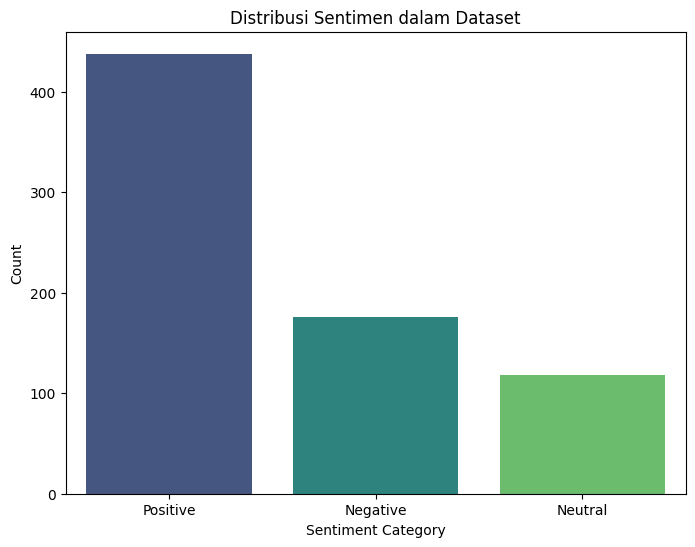

In [29]:
# Visualisasi distribusi Sentiment_Category
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment_Category', data=df, palette='viridis')
plt.title('Distribusi Sentimen dalam Dataset')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

# **Modeling**

In [30]:
# Define features (X) and target label (y)
X = df[['Cleaned_Text', 'Retweets', 'Likes', 'Hashtags', 'Platform']]
y = df['Sentiment_Category']

In [31]:
# Specify numeric, categorical, and text features
numeric_features = ['Retweets', 'Likes']
categorical_features = ['Hashtags', 'Platform']
text_feature = 'Cleaned_Text'

In [35]:
# Numeric processing: Imputation and scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Fill missing values with the mean
    ('scaler', StandardScaler())  # Scale features
])

In [36]:
# Categorical processing: Imputation and One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Fill missing with 'missing'
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Convert categories to binary
])

In [37]:
# Text processing: TF-IDF Vectorization
text_transformer = ('tfidf', TfidfVectorizer(stop_words='english'), text_feature)

# Combine all transformers into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
    text_transformer
])

In [38]:
# Build the full pipeline: preprocessing + SVM model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svm', SVC(kernel='linear', random_state=42))  # Linear kernel for classification
])

In [39]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
# Train the model
pipeline.fit(X_train, y_train)
# Predict the test set
y_pred = pipeline.predict(X_test)

# **Evaluasi**

In [41]:
# Predict using the trained model
y_pred = pipeline.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Classification Report
print("Classification Report for SVM:\n", classification_report(y_test, y_pred))

Classification Report for SVM:
               precision    recall  f1-score   support

    Negative       0.80      0.70      0.75        40
     Neutral       0.91      0.42      0.57        24
    Positive       0.79      0.96      0.87        83

    accuracy                           0.80       147
   macro avg       0.83      0.69      0.73       147
weighted avg       0.81      0.80      0.79       147



<Figure size 800x600 with 0 Axes>

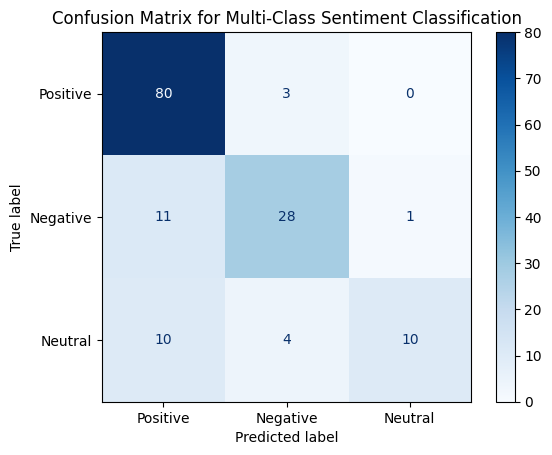

In [42]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Positive', 'Negative', 'Neutral'])

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative', 'Neutral'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Multi-Class Sentiment Classification')
plt.grid(False)
plt.show()

# **Deployment**

In [43]:
# Create a new DataFrame for deployment data
deploy_data = {
    'Cleaned_Text': [
        'love the weather today',
        'i feel sad about the news',
        'this product is amazing',
        'disappointed with the service',
        'just okay nothing special'
    ],
    'Retweets': [10, 2, 15, 1, 3],
    'Likes': [25, 5, 45, 3, 8],
    'Hashtags': ['#weather #happy', '#news #tragedy', '#review #product', '#service #bad', '#meh #neutral'],
    'Platform': ['Twitter', 'Facebook', 'Instagram', 'Twitter', 'Instagram']
}

deploy_df = pd.DataFrame(deploy_data)

# Save the DataFrame as a CSV file
deploy_df.to_csv('deploy_sample.csv', index=False)
print("✅ deploy_sample.csv file created successfully.")



✅ deploy_sample.csv file created successfully.


In [44]:
# Load the CSV file (simulating deployment)
deploy_loaded = pd.read_csv('deploy_sample.csv')

In [45]:
# Predict sentiment using the previously trained SVM pipeline
predictions = pipeline.predict(deploy_loaded)

# Add the predictions to the DataFrame
deploy_loaded['Predicted_Sentiment'] = predictions

# Show the final DataFrame with predictions
print(deploy_loaded[['Cleaned_Text', 'Platform', 'Predicted_Sentiment']])

                    Cleaned_Text   Platform Predicted_Sentiment
0         love the weather today    Twitter            Negative
1      i feel sad about the news   Facebook            Negative
2        this product is amazing  Instagram            Positive
3  disappointed with the service    Twitter            Negative
4      just okay nothing special  Instagram            Positive
